## Importing Required Libraries

In [1]:
# For reading, analysing and cleaning data
import pandas as pd
import numpy as np

# For plotting data
from matplotlib import pyplot as plt
import seaborn as sns

# For Feature selction and splitting data
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

# For model training
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# For evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

# For saving and loading model
import joblib

In [2]:
# reading dataset
data = pd.read_csv('Static_dataset.csv')
data.head()

,timestamp,FQDN_count,subdomain_length,upper,lower,numeric,entropy,special,labels,labels_max,labels_average,longest_word,sld,len,subdomain,Target Attack
0,56:19.8,27,10,0,10,11,2.570417,6,6,7,3.666667,2,192,14,1,1
1,07:23.9,27,10,0,10,11,2.767195,6,6,7,3.666667,2,192,14,1,1
2,23:15.1,26,9,0,10,10,2.742338,6,6,7,3.500000,2,192,13,1,0
3,04:51.9,27,10,0,10,11,2.570417,6,6,7,3.666667,2,192,14,1,1
4,12:44.0,15,9,0,11,0,2.929439,4,3,5,4.333333,local,local,15,1,1


In [3]:
data.shape

(268074, 16)

## Data Analysis

#### Checking number of Unique values and datatypes of each column

In [4]:
# prinintg each column's unique value and data type
for col in data.columns:
    print(f"{col} has {len(data[col].unique())} and datatype is {data[col].dtype}")

timestamp has 35924 and datatype is object
FQDN_count has 34 and datatype is int64
subdomain_length has 24 and datatype is int64
upper has 5 and datatype is int64
lower has 34 and datatype is int64
numeric has 13 and datatype is int64
entropy has 630 and datatype is float64
special has 8 and datatype is int64
labels has 7 and datatype is int64
labels_max has 31 and datatype is int64
labels_average has 73 and datatype is float64
longest_word has 6225 and datatype is object
sld has 11112 and datatype is object
len has 32 and datatype is int64
subdomain has 2 and datatype is int64
Target Attack has 2 and datatype is int64


#### Checking Imbalance data

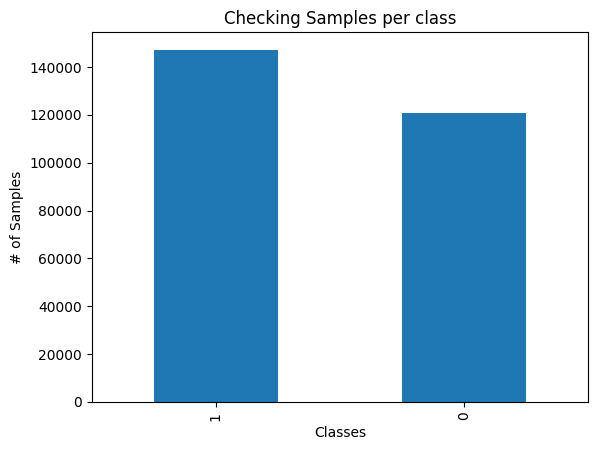

In [5]:
# take target variable and plots its unique value with frequency
data['Target Attack'].value_counts().plot(kind='bar')

plt.xlabel("Classes")
plt.ylabel("# of Samples")
plt.title("Checking Samples per class")
plt.show()

In [6]:
data['Target Attack'].value_counts() # just counting target class values

1    147179
0    120895
Name: Target Attack, dtype: int64

Since there are two classes and 'Class 1' has approx 27 thousands more sample than 'Class 0', so data is biased towards 'Class 1'. It will be set in data engineering steps.

#### Checking Skewness of Data

In [7]:
# print skewness of each feature
data.skew(axis=0, skipna = True, numeric_only=True)

FQDN_count         -1.101731
subdomain_length   -0.590480
upper               5.988737
lower               0.343449
numeric            -0.594384
entropy            -0.140156
special            -0.902972
labels             -0.903680
labels_max          3.979910
labels_average      5.087081
len                 2.634801
subdomain          -1.176397
Target Attack      -0.197046
dtype: float64

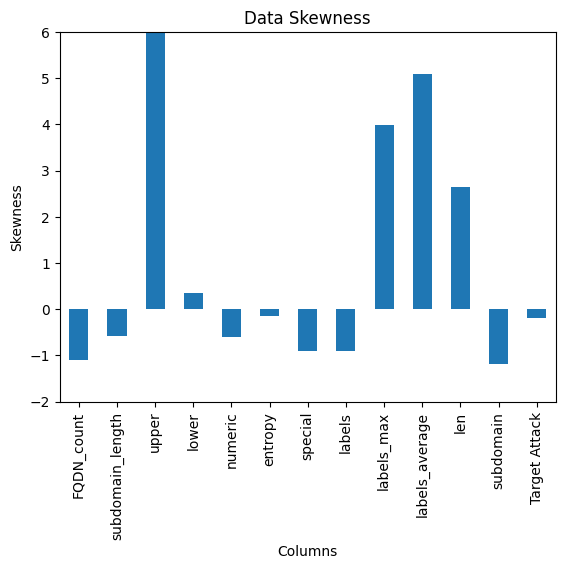

In [8]:
# ploting skewnes of each feature
data.skew(axis=0, skipna = True, numeric_only=True).plot(kind='bar')
plt.ylim((-2, 6))
plt.xlabel("Columns")
plt.ylabel("Skewness")
plt.title("Data Skewness")
plt.show()

If thhe skewness is between -0.5 and 0.5, the data are fairly distributed. If the skewness is between -1 and – 0.5 or between 0.5 and 1, the data are moderately skewed. If the skewness is less than -1 or greater than 1, the data are highly skewed.

Postive Skew Columns:
1. upper
2. labels_max
3. labels_average
4. len

Negative Skew Columns:
1. FDQN_count
2. subdomain

#### Data Distribution
Checking the data distribution of features and Target Label

In [9]:
# data discription
data.describe()

,FQDN_count,subdomain_length,upper,lower,numeric,entropy,special,labels,labels_max,labels_average,len,subdomain,Target Attack
count,268074.000000,268074.000000,268074.000000,268074.000000,268074.000000,268074.000000,268074.000000,268074.000000,268074.000000,268074.000000,268074.000000,268074.000000,268074.000000
mean,22.286596,6.059021,0.845420,10.410014,6.497586,2.485735,4.533577,4.788823,8.252233,4.802239,12.576714,0.753497,0.549024
std,6.001205,3.899505,4.941929,3.207725,4.499866,0.407709,2.187683,1.803256,4.415355,4.573066,4.177828,0.430975,0.497592
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.219195,0.000000,1.000000,2.000000,2.000000,2.000000,0.000000,0.000000
25%,18.000000,3.000000,0.000000,10.000000,0.000000,2.054029,2.000000,3.000000,7.000000,3.166667,11.000000,1.000000,0.000000
50%,24.000000,7.000000,0.000000,10.000000,8.000000,2.570417,6.000000,6.000000,7.000000,3.666667,12.000000,1.000000,1.000000
75%,27.000000,10.000000,0.000000,10.000000,10.000000,2.767195,6.000000,6.000000,7.000000,4.000000,14.000000,1.000000,1.000000
max,36.000000,23.000000,32.000000,34.000000,12.000000,4.216847,7.000000,7.000000,32.000000,32.000000,33.000000,1.000000,1.000000


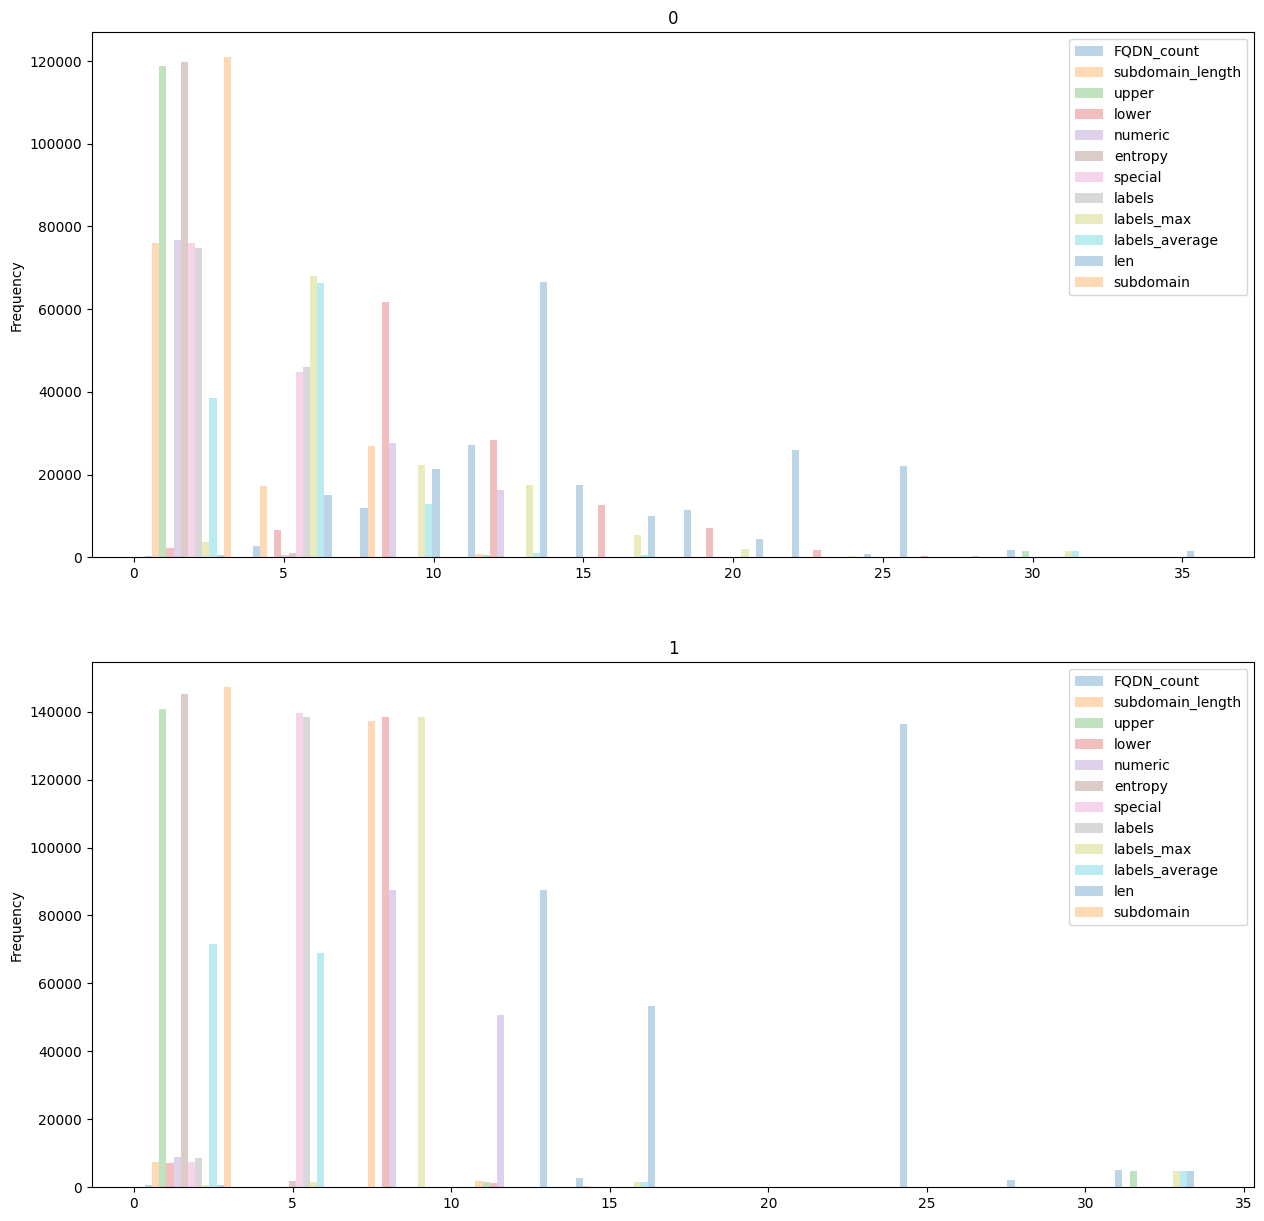

In [10]:
# plotting data discription
data.plot.hist(by="Target Attack", figsize=(15, 15), alpha=0.3)
plt.show()

## Data Cleaning

#### Removing Null Values

In [11]:
# checking number of null values in each column
data.isna().sum()

timestamp           0
FQDN_count          0
subdomain_length    0
upper               0
lower               0
numeric             0
entropy             0
special             0
labels              0
labels_max          0
labels_average      0
longest_word        8
sld                 0
len                 0
subdomain           0
Target Attack       0
dtype: int64

Since number of null values are very less, so we can remove them without effecting data

In [12]:
# deleting rows whihc contain null value in any column
data.dropna(axis=1, inplace=True)

In [13]:
data.isna().sum()

timestamp           0
FQDN_count          0
subdomain_length    0
upper               0
lower               0
numeric             0
entropy             0
special             0
labels              0
labels_max          0
labels_average      0
sld                 0
len                 0
subdomain           0
Target Attack       0
dtype: int64

All null values has been removed

#### Converting Categorical data to Numerical
As We have seen above in datatypes of dataset, there are only 3 column which are object:
1. timestamp (it will be excluded because it does not play important role in classification)
2. sld
3. len

So checks for categorical data will be applied only to them.

In [14]:
# converting categorical data to numeircal using encoding
data['sld'] = data['sld'].astype('category').cat.codes

In [15]:
data['len'] = data['len'].astype('category').cat.codes

In [16]:
# checking data types after conversion
data.dtypes

timestamp            object
FQDN_count            int64
subdomain_length      int64
upper                 int64
lower                 int64
numeric               int64
entropy             float64
special               int64
labels                int64
labels_max            int64
labels_average      float64
sld                   int16
len                    int8
subdomain             int64
Target Attack         int64
dtype: object

Data is converted into numerical form (except timestamp which will be removed later)

## Data Selection

In [17]:
# Dropping  timestamp column, because time has not effect on data
data.drop(columns=['timestamp'], inplace=True)

#### Filter Method
Using Pearson's Corelation technique

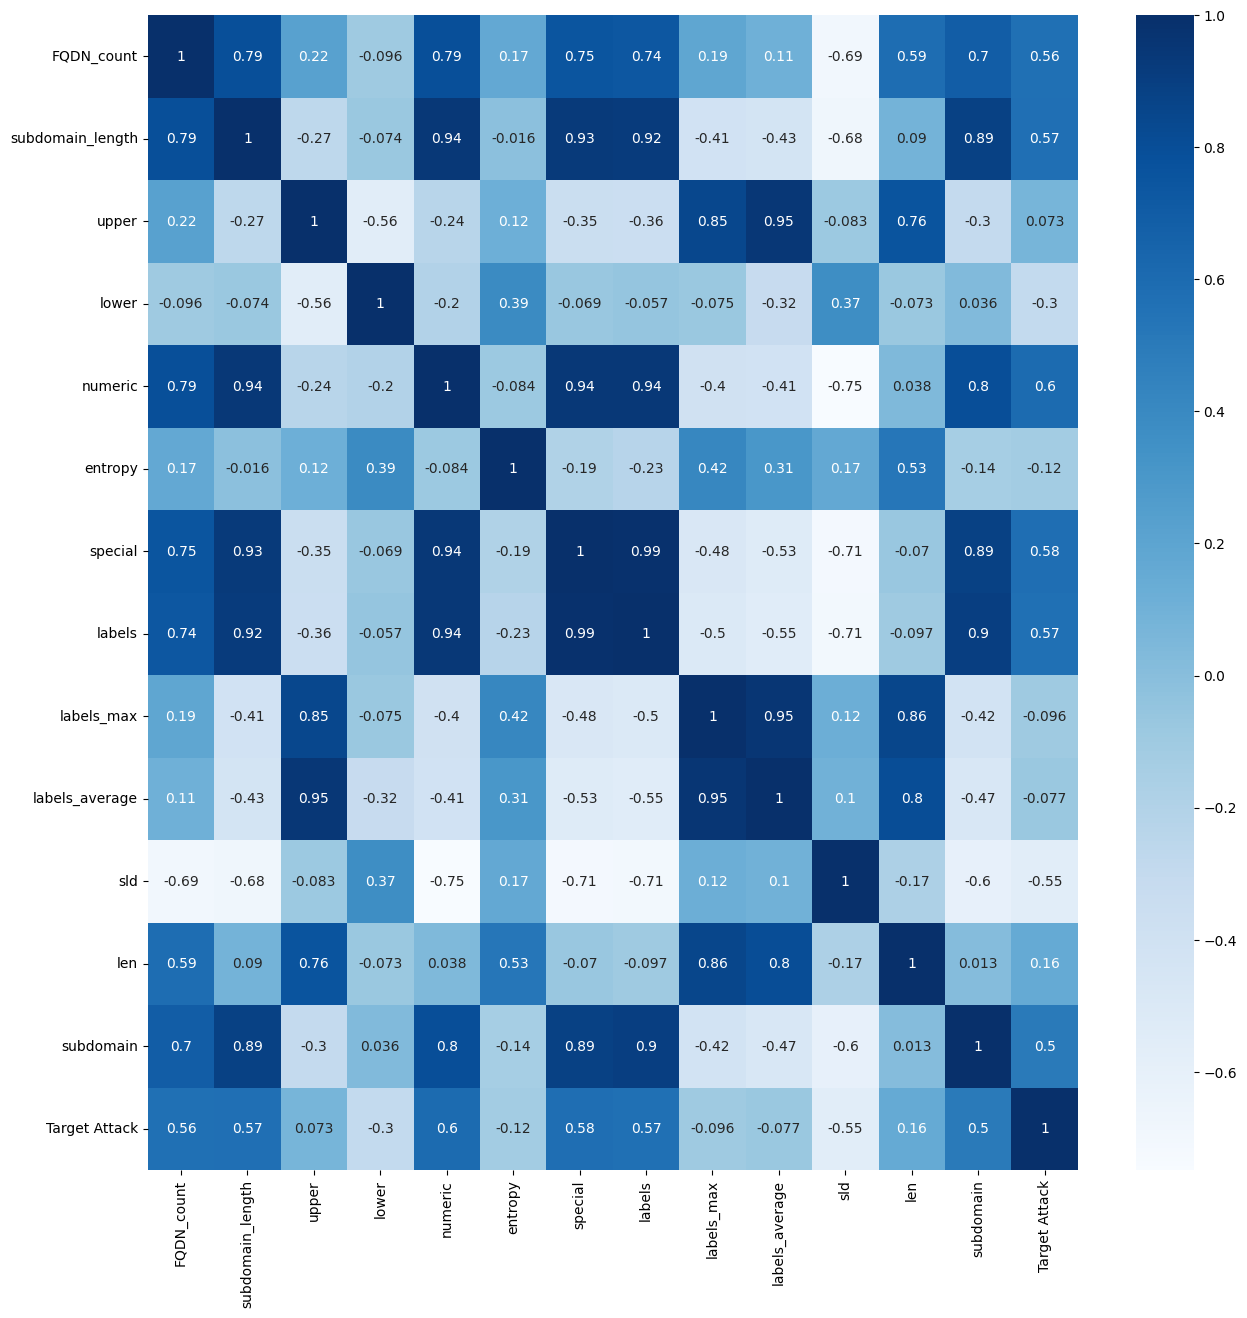

In [18]:
# plot correlation of each column with other
plt.figure(figsize=(15,15))
corelations = data.corr()
sns.heatmap(corelations, annot=True, cmap=plt.cm.Blues)
plt.show()

In [19]:
# droping feature which have correlation <= 0.5 with target variable
corelation = abs(corelations['Target Attack'])
columns = corelation[corelation > 0.5]
columns

FQDN_count          0.563563
subdomain_length    0.572053
numeric             0.599252
special             0.582107
labels              0.569414
sld                 0.553529
subdomain           0.502469
Target Attack       1.000000
Name: Target Attack, dtype: float64

#### Warpper Method
Using Recursive Feature Elimination

In [20]:
# splitting features and target variable
X = data[data.columns[:-1]]
y = data['Target Attack']

In [21]:
model = GradientBoostingClassifier()

In [22]:
# selecting 7 best features using recursuve feature elimination
cols = list(X.columns)
rfe = RFE(model, n_features_to_select=7)
X_rfe = rfe.fit_transform(X,y)
model.fit(X_rfe,y)  

temp = pd.Series(rfe.support_, index = cols) # gives a list of ture and false with columns names
columns= temp[temp==True].index.values
print(f"Featues that are selected: {columns}")

Featues that are selected: ['FQDN_count' 'subdomain_length' 'upper' 'lower' 'special' 'labels' 'sld']


#### Choosing Most Effective Features

In [23]:
# selecting only features which are best
columns = list(columns)
columns.append("Target Attack")
selected_data = data[columns]

In [24]:
selected_data.head()

,FQDN_count,subdomain_length,upper,lower,special,labels,sld,Target Attack
0,27,10,0,10,6,6,35,1
1,27,10,0,10,6,6,35,1
2,26,9,0,10,6,6,35,0
3,27,10,0,10,6,6,35,1
4,15,9,0,11,4,3,5622,1


#### Spliting Data into Train and Test

In [25]:
X = selected_data[columns[:-1]].values
y = selected_data[columns[-1]].values

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Model Training

#### 1. XGBoost

In [27]:
# training gradient boosting
xgb = GradientBoostingClassifier()
xgb.fit(X_train, y_train)

GradientBoostingClassifier()

#### 2. Gaussian Naive Bayes

In [28]:
# training gaussian naive bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

## Evaluation

#### 1.XGBoost

Accuracy of XGBoost is 0.8274519166206599


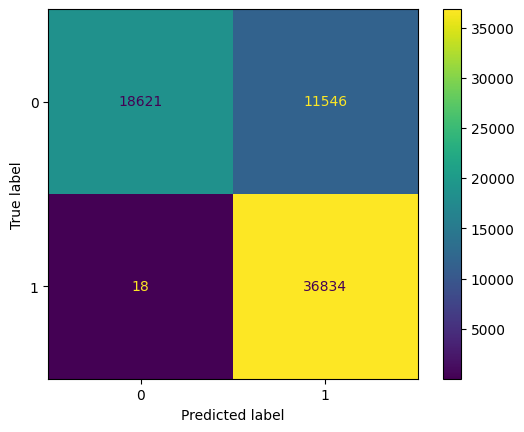

In [29]:
# printing results of gradient boosting trees
xgb_prediction = xgb.predict(X_test)
print(f"Accuracy of XGBoost is {accuracy_score(xgb_prediction, y_test)}")
cm = confusion_matrix(y_test, xgb_prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()

#### 2. Gaussian Naive Bayes

Accuracy of Gaussian Naive Bayes is 0.817350303645235


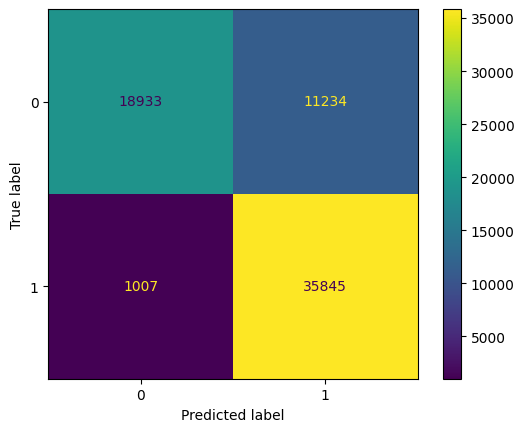

In [30]:
# printing results of gaussin naive bayes
gnb_prediction = gnb.predict(X_test)
print(f"Accuracy of Gaussian Naive Bayes is {accuracy_score(gnb_prediction, y_test)}")
cm = confusion_matrix(y_test, gnb_prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()

## Final Result

While seeing the accuracy of both models, I will choose the XGBoost in the 2nd part of assignment

## Saving best model

In [31]:
joblib.dump(xgb, "static_model.pkl")

['static_model.pkl']